In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [15]:
train_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')


In [16]:

print(train_data.describe())
print(train_data.head())


                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

In [17]:
print("Missing values in train data:")
print(train_data.isnull().sum().sort_values(ascending=False))

print("\nMissing values in test data:")
print(test_data.isnull().sum().sort_values(ascending=False))


Missing values in train data:
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

Missing values in test data:
PoolQC           1456
MiscFeature      1408
Alley            1352
Fence            1169
MasVnrType        894
                 ... 
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
SaleCondition       0
Length: 80, dtype: int64


In [18]:
# Fill numerical columns with median
for col in train_data.select_dtypes(include=['int64', 'float64']):
    train_data[col] = train_data[col].fillna(train_data[col].median())
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(train_data[col].median())

# Fill categorical columns with mode
for col in train_data.select_dtypes(include=['object']):
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(train_data[col].mode()[0])


In [19]:
# Apply one-hot encoding
train_data = pd.get_dummies(train_data, drop_first=True)
test_data = pd.get_dummies(test_data, drop_first=True)

# Align train and test datasets (to ensure they have the same columns)
X_train, test_data = train_data.align(test_data, join='inner', axis=1)


In [20]:
# Target variable
y_train = train_data['SalePrice']

# Training features (drop target variable)
X_train = X_train.drop('SalePrice', axis=1, errors='ignore')


In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
model = RandomForestRegressor(random_state=42, n_estimators=100)

# Train the model
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [22]:
# Predict on test data
test_predictions = model.predict(test_data)


In [23]:
# Create a submission DataFrame
submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")


Submission file created successfully!


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


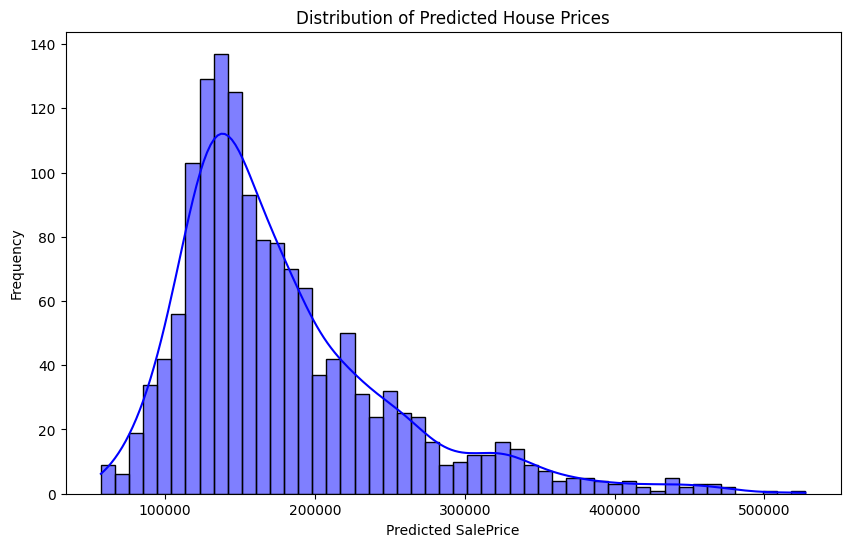

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of predicted house prices
plt.figure(figsize=(10, 6))
sns.histplot(submission['SalePrice'], bins=50, kde=True, color='blue')
plt.title('Distribution of Predicted House Prices')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Frequency')
plt.show()


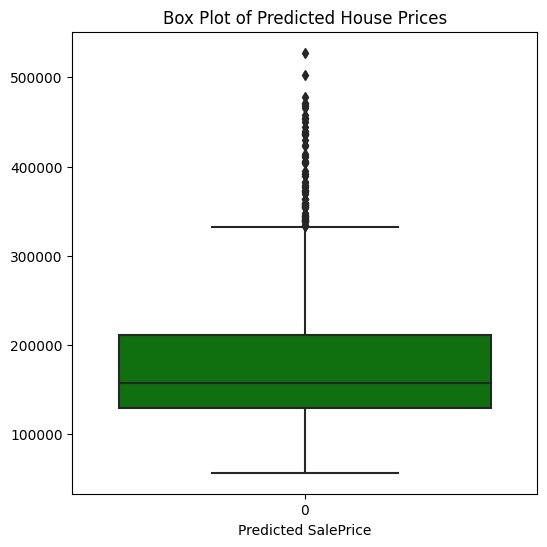

In [26]:
# Box plot of predicted prices
plt.figure(figsize=(6, 6))
sns.boxplot(data=submission['SalePrice'], color='green')
plt.title('Box Plot of Predicted House Prices')
plt.xlabel('Predicted SalePrice')
plt.show()
